# Fase 1b — Análisis exploratorio (EDA) de la demanda NYC
**TFM Pau Gavilán — Predicción de demanda para taxistas autónomos**

Este notebook explora la tabla de demanda generada por `fase1_descarga_demanda.py`:
`data/processed/demanda_nyc_2023.parquet`, con una fila por **(zona × fecha × hora)** y la columna `demanda` = nº de recogidas.

Objetivo: entender los patrones espacio-temporales **antes** de modelar (Fase 2).

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Raíz del proyecto: funciona tanto si abres el notebook desde notebooks/
# como si lanzas Jupyter desde la raíz del repositorio.
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

PARQUET_PATH = ROOT / 'data' / 'processed' / 'demanda_nyc_2023.parquet'

df = pd.read_parquet(PARQUET_PATH)
df['fecha'] = pd.to_datetime(df['fecha'])

# Nombre de día (DuckDB dow: 0=Domingo ... 6=Sábado), ordenado de Lun a Dom
dias = {0: 'Dom', 1: 'Lun', 2: 'Mar', 3: 'Mié', 4: 'Jue', 5: 'Vie', 6: 'Sáb'}
orden = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
df['dia_nombre'] = pd.Categorical(df['dia_semana'].map(dias), categories=orden, ordered=True)
df['mes'] = df['fecha'].dt.month

df.head()

,zona,nombre_zona,distrito,fecha,hora,dia_semana,es_finde,demanda,dia_nombre,mes
0,1,Newark Airport,EWR,2023-01-01,0,0,True,0,Dom,1
1,1,Newark Airport,EWR,2023-01-01,1,0,True,0,Dom,1
2,1,Newark Airport,EWR,2023-01-01,2,0,True,0,Dom,1
3,1,Newark Airport,EWR,2023-01-01,3,0,True,0,Dom,1
4,1,Newark Airport,EWR,2023-01-01,4,0,True,0,Dom,1


## 1. Vista general y chequeo de sanidad
Tamaño, rango de fechas, nº de zonas y — muy importante — **qué porcentaje de la rejilla es 0** (la dispersión condiciona el modelo y la métrica).

In [2]:
print(f'Filas:            {len(df):,}')
print(f'Zonas:            {df["zona"].nunique()}')
print(f'Rango de fechas:  {df["fecha"].min().date()}  ->  {df["fecha"].max().date()}')
print(f'Recogidas totales:{df["demanda"].sum():,}')
print(f'% de celdas con demanda 0: {(df["demanda"] == 0).mean() * 100:.1f}%')
print()
df['demanda'].describe()

Filas:            2,303,880
Zonas:            263
Rango de fechas:  2023-01-01  ->  2023-12-31
Recogidas totales:38,310,122
% de celdas con demanda 0: 61.5%



count    2.303880e+06
mean     1.662852e+01
std      5.129474e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.000000e+00
max      1.106000e+03
Name: demanda, dtype: float64

## 2. Demanda por hora del día
La curva diaria: valle de madrugada y picos de mañana/tarde. Es la señal temporal más fuerte.

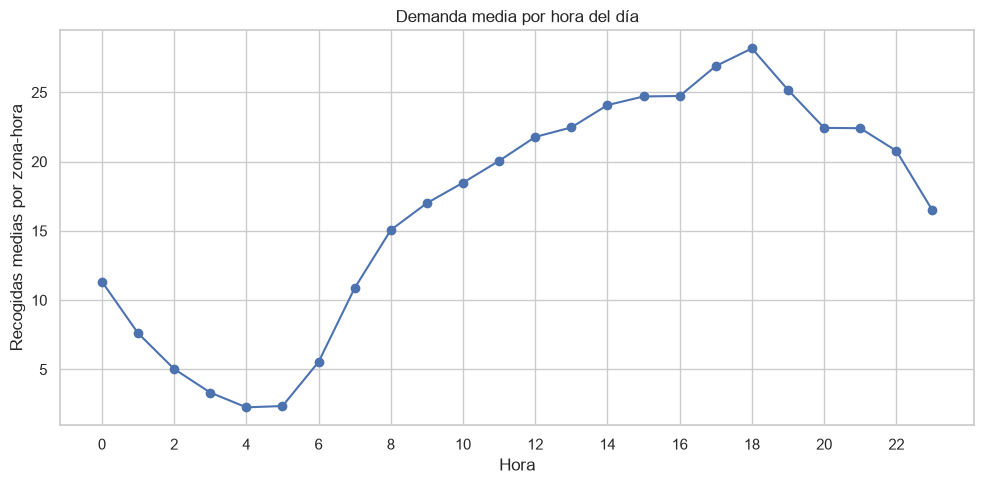

In [3]:
por_hora = df.groupby('hora')['demanda'].mean()

ax = por_hora.plot(marker='o')
ax.set_title('Demanda media por hora del día')
ax.set_xlabel('Hora')
ax.set_ylabel('Recogidas medias por zona-hora')
ax.set_xticks(range(0, 24, 2))
plt.tight_layout(); plt.show()

## 3. Demanda por día de la semana
¿Trabaja más la ciudad entre semana o el fin de semana? (en NYC suele subir noche de viernes/sábado).

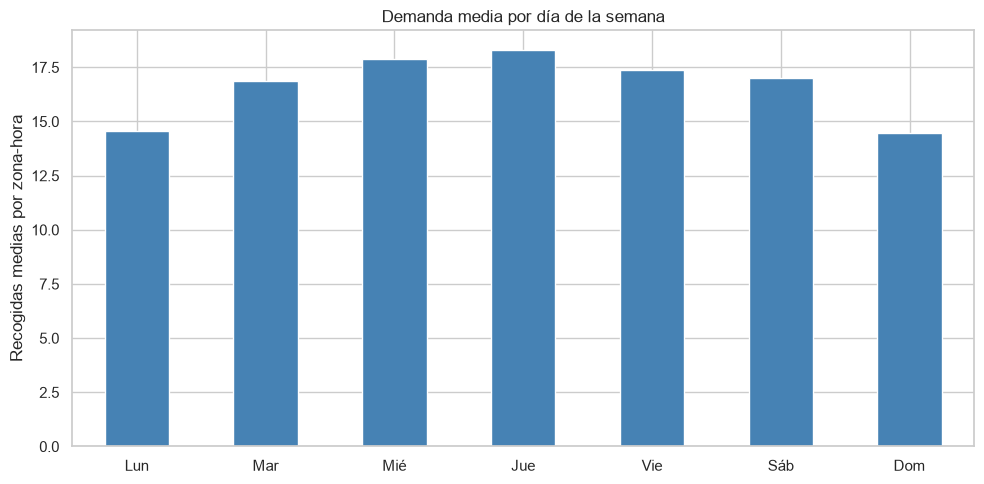

In [4]:
por_dia = df.groupby('dia_nombre', observed=False)['demanda'].mean()

ax = por_dia.plot(kind='bar', color='steelblue')
ax.set_title('Demanda media por día de la semana')
ax.set_xlabel(''); ax.set_ylabel('Recogidas medias por zona-hora')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 4. Mapa de calor: hora × día de la semana
El patrón espacio-temporal clásico. Aquí se ve dónde están los picos combinados (p. ej. tardes de finde vs horas punta laborables).

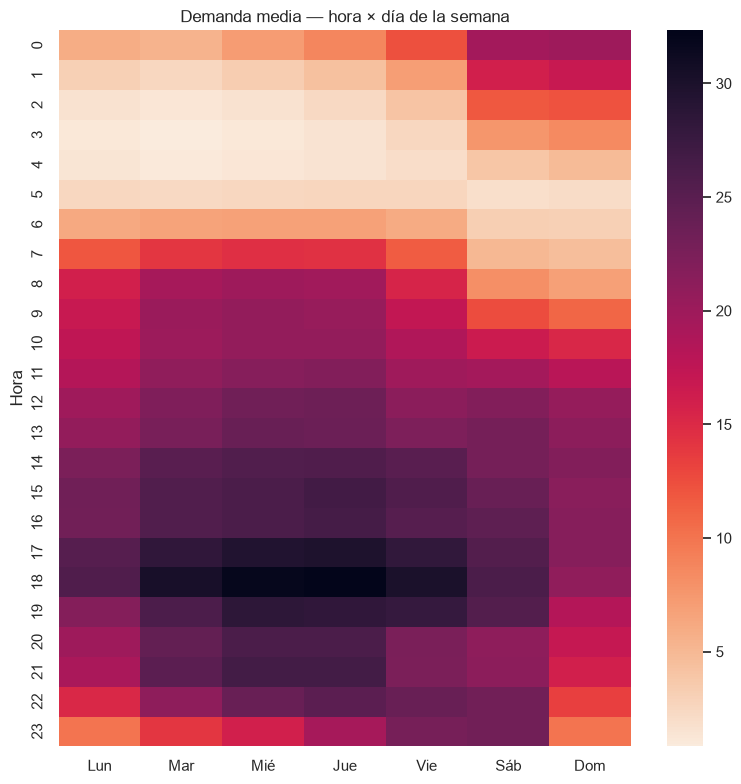

In [5]:
pivot_hd = df.pivot_table(index='hora', columns='dia_nombre', values='demanda',
                          aggfunc='mean', observed=False)

plt.figure(figsize=(8, 8))
sns.heatmap(pivot_hd, cmap='rocket_r', annot=False)
plt.title('Demanda media — hora × día de la semana')
plt.xlabel(''); plt.ylabel('Hora')
plt.tight_layout(); plt.show()

## 5. Zonas que concentran la demanda
La dimensión espacial: las 15 zonas con más recogidas en todo el año.

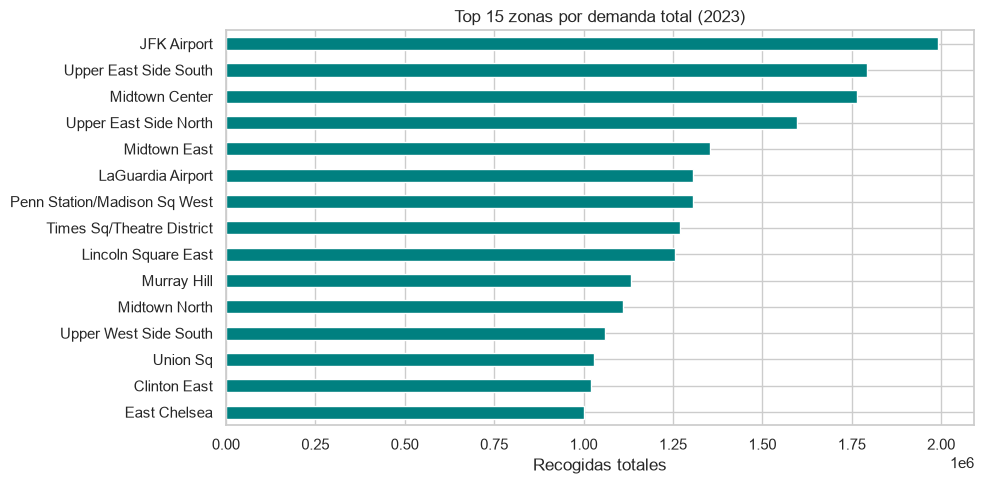

In [6]:
top = (df.groupby('nombre_zona')['demanda'].sum()
         .sort_values(ascending=False).head(15))

ax = top.sort_values().plot(kind='barh', color='teal')
ax.set_title('Top 15 zonas por demanda total (2023)')
ax.set_xlabel('Recogidas totales'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

## 6. Mapa de calor: zona (top 15) × hora
Une espacio y tiempo: ¿cada zona top tiene su propia 'hora punta'? Esto es justo lo que el producto debe recomendar al conductor.

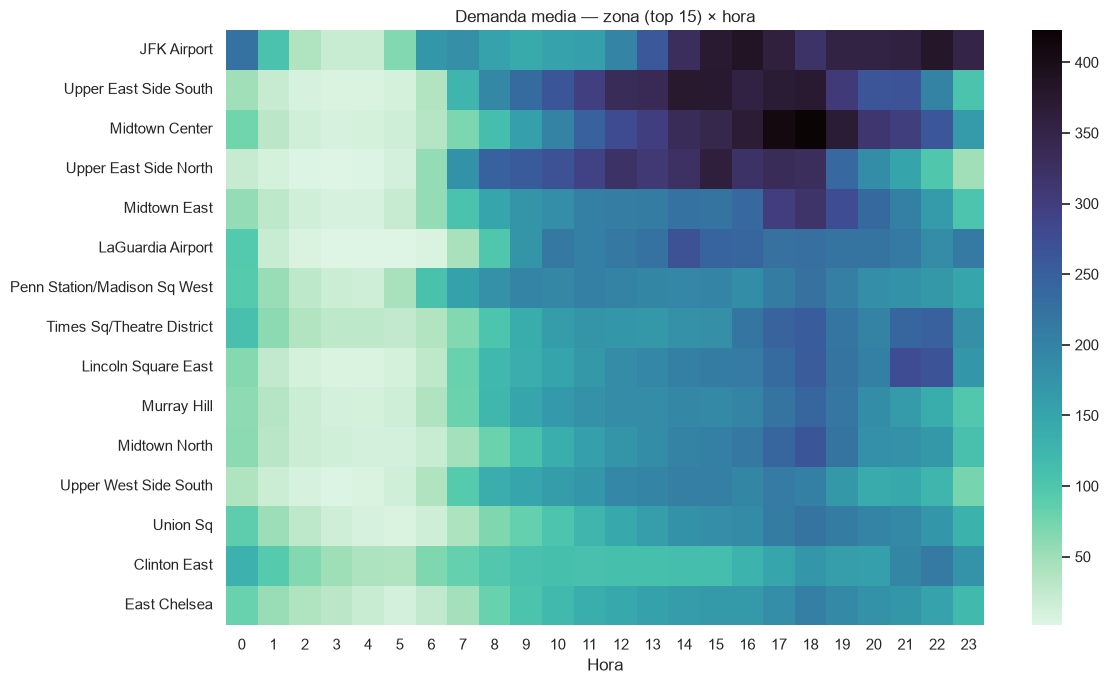

In [7]:
sub = df[df['nombre_zona'].isin(top.index)]
pivot_zh = sub.pivot_table(index='nombre_zona', columns='hora', values='demanda',
                           aggfunc='mean').reindex(top.index)

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_zh, cmap='mako_r')
plt.title('Demanda media — zona (top 15) × hora')
plt.xlabel('Hora'); plt.ylabel('')
plt.tight_layout(); plt.show()

## 7. Fin de semana vs. día laborable
Comparamos las dos curvas horarias. El cambio de forma justifica usar `es_finde` como variable en el modelo.

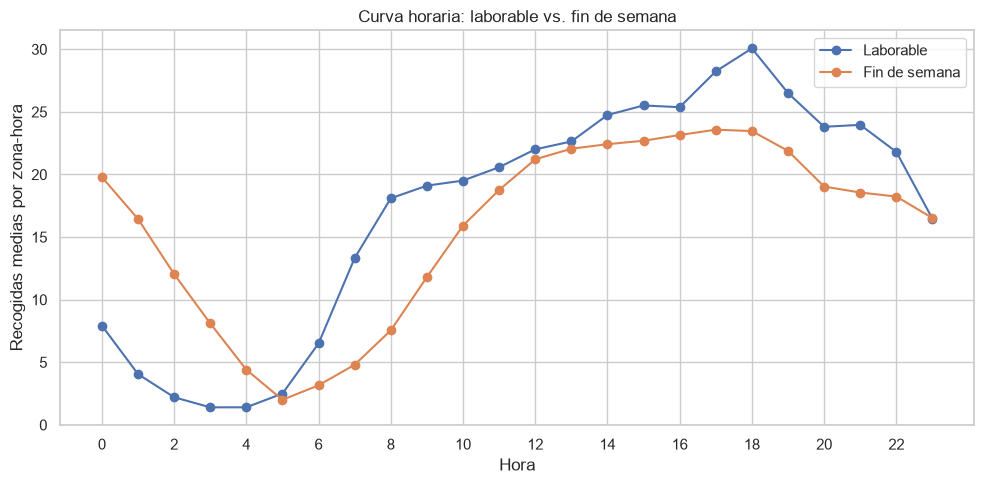

In [8]:
comp = df.groupby(['es_finde', 'hora'])['demanda'].mean().unstack(0)
comp.columns = ['Laborable', 'Fin de semana']

ax = comp.plot(marker='o')
ax.set_title('Curva horaria: laborable vs. fin de semana')
ax.set_xlabel('Hora'); ax.set_ylabel('Recogidas medias por zona-hora')
ax.set_xticks(range(0, 24, 2))
plt.tight_layout(); plt.show()

## 8. Distribución de la demanda (¡ojo con los ceros!)
Muchas celdas valen 0 o muy poco. Esta **dispersión** es la razón por la que NO usaremos MAPE a secas (división por cero) y sí MAE / RMSE / WAPE en la Fase 2.

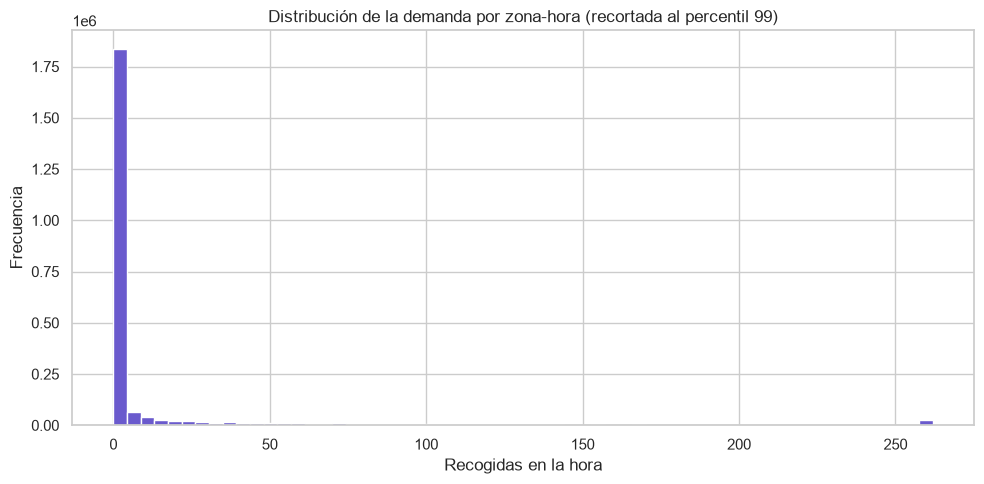

% celdas con demanda 0: 61.5%
Mediana: 0   |   Media: 16.6


In [9]:
ax = df['demanda'].clip(upper=df['demanda'].quantile(0.99)).hist(bins=60, color='slateblue')
ax.set_title('Distribución de la demanda por zona-hora (recortada al percentil 99)')
ax.set_xlabel('Recogidas en la hora'); ax.set_ylabel('Frecuencia')
plt.tight_layout(); plt.show()

print(f'% celdas con demanda 0: {(df["demanda"] == 0).mean() * 100:.1f}%')
print(f'Mediana: {df["demanda"].median():.0f}   |   Media: {df["demanda"].mean():.1f}')

## 9. Serie temporal anual
Demanda diaria total a lo largo de 2023. Busca **estacionalidad**, caídas en **festivos** y posibles **anomalías** (tormentas, eventos) — esto enlaza con tu componente de detección de anomalías.

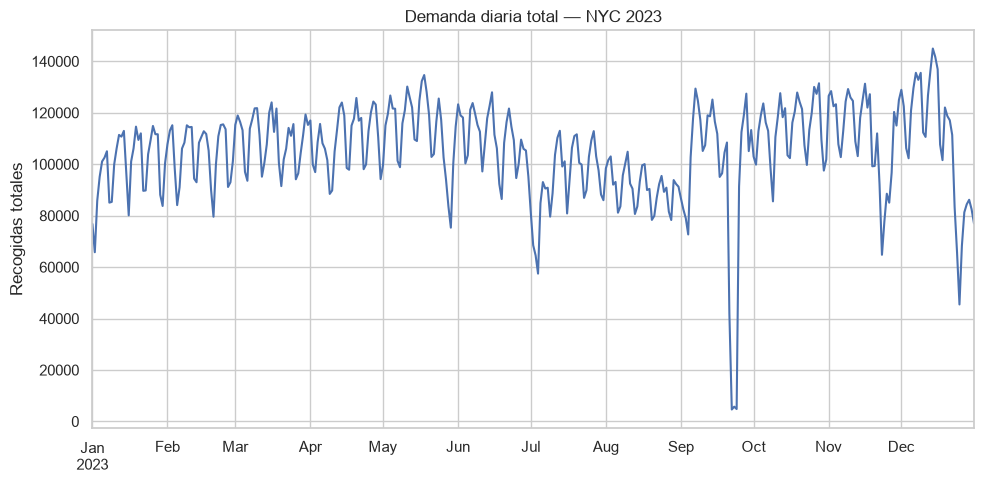

In [10]:
diaria = df.groupby('fecha')['demanda'].sum()

ax = diaria.plot()
ax.set_title('Demanda diaria total — NYC 2023')
ax.set_xlabel(''); ax.set_ylabel('Recogidas totales')
plt.tight_layout(); plt.show()

## 10. Conclusiones y puente a la Fase 2
Apunta lo que observes (rellena tras ejecutar):

- **Patrón horario:** valle de madrugada, picos de 8-10h y 18-19h.
- **Patrón semanal:** mínimo el domingo; máximo jueves-viernes.
- **Zonas dominantes:** Manhattan: Midtown, Upper East Side, y los aeropuertos (JFK, LaGuardia), Penn Station/Times Sq.
- **Dispersión:** ~62% de ceros → métricas MAE/RMSE/WAPE, no MAPE.

**Variables (features) que ya se justifican para el modelo:**
- Temporales: `hora`, `dia_semana`, `mes`, `es_finde`, festivo (sí/no).
- **Lags**: demanda de la misma zona hace 1h, 24h y 168h (semana) + medias móviles.
- Externas: clima (Open-Meteo), eventos.
- Zona: identificador categórico.

Siguiente paso (Fase 2): construir estas features y lanzar la comparativa **baseline → Prophet → LightGBM → LSTM** con validación temporal.